In [3]:
import sys
from typing import Literal

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display
from matplotlib.ticker import FuncFormatter
from scipy.stats import genpareto, lognorm, truncpareto

from pandemic_model.stats.mevd import mevd_gen
from pandemic_model.stats.pareto import fit_trunc_pareto

sys.path.append("../scripts")
from fit_distributions import fit_truncated_pareto

In [4]:
all_epidemics_ds = pd.read_excel("../../data/raw/epidemics_marani_240816.xlsx")
all_epidemics_ds = all_epidemics_ds.rename(columns={'severity_smu': 'severity'}) # Name change simplifies code later

In [5]:
with open("../../data/clean/inverted_covid_severity.yaml", 'rb') as f:
  inverted_covid_severity_dict = yaml.safe_load(f)
  inverted_covid_severity = inverted_covid_severity_dict['ex_ante_severity']

In [6]:
all_epidemics_ds['intensity'] = all_epidemics_ds['severity'] / all_epidemics_ds['duration']

#### Construct datasets

In [7]:
bernstein_additions = ['hiv/aids', 'covid-19'] # Anything else we added?
marani_raw_ds = all_epidemics_ds[~all_epidemics_ds['disease'].isin(bernstein_additions)]
marani_fit_ds = marani_raw_ds[marani_raw_ds['year_end'].between(1600, 1945)]
all_modern_ds = all_epidemics_ds[all_epidemics_ds['year_start'] >= 1900]
modern_viral_ds = all_modern_ds[all_modern_ds['type'].str.contains('viral', case=False)]

In [8]:
modern_viral_ds['disease'].value_counts().sort_values(ascending=False)

disease
polio                         19
influenza                     18
smallpox                      13
meningitis                    11
measles                        9
dengue                         9
encephalitis                   8
yellow fever                   6
pneumonia                      5
murray valley encephalitis     4
ebola                          3
west nile                      2
rubella                        2
mumps                          1
kyasanur forest disease        1
hemorrhagic fever              1
rift valley fever              1
hiv/aids                       1
sars                           1
mers                           1
covid-19                       1
Name: count, dtype: int64

In [9]:
# Not sure about these
recurring_viruses = ['polio', 'smallpox', 'meningitis', 'measles', 'dengue',
                     'encephalitis', 'yellow fever', 'pneumonia', 'murray valley encephalitis',
                     'rubella', 'mumps']
non_resp_novel = ['ebola', 'west nile', 'kyasanur forest disease', 'hemorrhagic fever', 'rift valley fever', 'hiv/aids']

In [10]:
modern_viral_no_reccuring = modern_viral_ds[~modern_viral_ds['disease'].isin(recurring_viruses)]
modern_resp_novel = modern_viral_no_reccuring[~modern_viral_no_reccuring['disease'].isin(non_resp_novel)]

In [11]:
bernstein_intersect_ds = pd.read_excel("../../data/raw/novel_resp_241228.xlsx")
bernstein_intersect_ds = bernstein_intersect_ds.rename(columns={'severity_smu': 'severity'})

In [12]:
fit_dfs = {
		'All 1600-1945 (Marani)': marani_fit_ds,
		'All since 1900': all_modern_ds, 
		'Viral since 1900': modern_viral_ds,
		'Viral since 1900, no recurring': modern_viral_no_reccuring,
		'Respiratory since 1900': modern_resp_novel,
		'Novel since 1900 (Bernstein)': bernstein_intersect_ds
}

### Fit distributions

In [13]:
def get_pareto_dist(df: pd.DataFrame,
                    col: Literal['severity', 'intensity'],
                    disttype: Literal['gpd', 'trunc'],
                    lower_bound: float = 1e-2,
                    upper_bound: float = 1e4):
		"""Get exceedance distribution."""
		fit_df = df.copy()
		
		# Drop observations below lower bound
		fit_df = fit_df[fit_df[col] >= lower_bound]
				
		if disttype == 'gpd':
				c, loc, scale = genpareto.fit(fit_df[col], floc=lower_bound)
				dist = genpareto(c=c, loc=loc, scale=scale)                         
		else:
				(b, loc, scale), _ = fit_truncated_pareto(fit_df[col], lower_bound, upper_bound)
				c = (upper_bound - loc) / scale
				dist = truncpareto(b=b, c=c, loc=loc, scale=scale)

		return dist


def preprocess_df(df, drop_hiv, use_inverted_covid):
		new_df = df.copy()
		
		if drop_hiv:
				new_df = new_df[new_df['disease'] != 'hiv/aids']
		
		if use_inverted_covid:
				covid_mask = new_df['disease'] == 'covid-19'
				new_df.loc[covid_mask, 'severity'] = inverted_covid_severity
		
		new_df['intensity'] = new_df['severity'] / new_df['duration']
		return new_df

In [14]:
def get_datasets_and_distributions(lower_bound=1e-2,
                                   drop_hiv=False,
                                   use_inverted_covid=False):
    """
    Creates plots comparing exceedance functions between generalized and truncated Pareto fits
    for both severity and intensity data.
    
    Args:
        lower_bound (float): Lower bound threshold for fitting distributions
        drop_hiv (bool): Whether to exclude HIV/AIDS observation
        use_inverted_covid (bool): Whether to use inverted COVID-19 severity
    
    Returns:
        dict: Dictionary containing the processed dataframes and fitted distributions
    """
    # Should probably define elsewhere
    upper_bounds = {
      'severity': {
        'gpd': None,
        'trunc': 1e4
			},
      'intensity': {
        'gpd': None,
        'trunc': 1e4
			}
		}
  
    # Process all dataframes
    processed_dfs = {name: preprocess_df(df, drop_hiv, use_inverted_covid) for name, df in fit_dfs.items()}
    
    # Fit distributions
    distributions = {}
    for name, df in processed_dfs.items():
        distributions[name] = {
            metric: {
                dist_type: get_pareto_dist(
                    df,
                    metric,
                    dist_type,
                    lower_bound,
                    upper_bounds[metric][dist_type]
                )
                for dist_type in ['gpd', 'trunc']
            }
            for metric in ['severity', 'intensity']
        }
    
    return {'dfs': processed_dfs, 'distributions': distributions}

In [15]:
# Get arrival counts for MEVD
def get_annual_arrival_counts(df: pd.DataFrame, start_year, end_year):
		years = np.arange(start_year, end_year + 1)
		arrival_counts = pd.Series(0, index=years)

		eval_df = df[df['year_start'].between(start_year, end_year)]
		df_counts = eval_df.groupby('year_start').size()
		arrival_counts.loc[df_counts.index] = df_counts

		return arrival_counts


arrival_count_dfs = {
		'All 1600-1945 (Marani)': marani_raw_ds,
		'All since 1900': all_modern_ds, 
		'Viral since 1900': modern_viral_ds,
		'Viral since 1900, no recurring': modern_viral_no_reccuring,
		'Respiratory since 1900': modern_resp_novel,
		'Novel since 1900 (Bernstein)': bernstein_intersect_ds
}
		
long_arrival_windows = {
		'All 1600-1945 (Marani)': [1600, 1945],
		'All since 1900': [1900, 2019], 
		'Viral since 1900': [1900, 2019],
		'Viral since 1900, no recurring': [1900, 2019],
		'Respiratory since 1900': [1900, 2019],
		'Novel since 1900 (Bernstein)': [1900, 2019]
}

In [16]:
def get_share_above_threshold(df, col, thresh):
    return (
        len(df[df[col] >= thresh]) / len(df)
        if len(df) > 0 
        else 0
    )

In [17]:
# Interactive plotting code
def create_arrival_plot():
    """Creates and displays the interactive plot with all controls."""
    
    def update_plot(
      	lower_bound,
        show_gpd,
        show_trunc,
        use_recent_arrival_counts,
        selected_dfs,
        use_extinction_upper,
        drop_hiv,
        use_inverted_covid
    ):
        """Updates and returns the plot based on the selected parameters.
        
        Args:
            lower_bound (float): Lower bound for fitting distributions
            show_gpd (bool): Whether to show generalized Pareto distribution curves
            show_trunc (bool): Whether to show truncated distribution curves 
            use_recent_arrival_counts (bool): Whether to use short or long run arrival counts.
            use_above_threshold_rate (bool): Whether to adjust rates for above threshold events
            selected_dfs (list): List of selected datasets to plot
            use_extinction_upper (bool): Whether to use extinction upper bounds
            drop_hiv (bool): Whether to exclude HIV data
            use_inverted_covid (bool): Whether to use inverted COVID data
            
        Returns:
            matplotlib.figure.Figure: The updated figure
        """
        # Get initial datasets and distributions
        out = get_datasets_and_distributions(
						lower_bound=lower_bound,
						drop_hiv=drop_hiv,
						use_inverted_covid=use_inverted_covid
				)
        processed_dfs = out['dfs']
        distributions = out['distributions']

        fig, (ax_sev, ax_int) = plt.subplots(1, 2, figsize=(16, 8))
        
        # Generate points for theoretical curves
        x = np.logspace(np.log10(lower_bound), np.log10(1e4), 1000)
        
        for name in selected_dfs:
            df = processed_dfs[name]

            # Plot for both severity and intensity
            for ax, metric in [(ax_sev, 'severity'), (ax_int, 'intensity')]:
                
                arrival_window = [2000, 2019] if use_recent_arrival_counts else long_arrival_windows[name]
                arrival_count_df = arrival_count_dfs[name]
                arrival_count_df = preprocess_df(arrival_count_df, drop_hiv, use_inverted_covid)
                arrival_count_df = arrival_count_df[arrival_count_df[metric] >= lower_bound]
                arrival_counts = get_annual_arrival_counts(arrival_count_df, *arrival_window)
                            
                if show_gpd:
                    base_dist = distributions[name][metric]['gpd']
                    mevd_gpd = mevd_gen(arrival_counts, base_dist)
                    y_gpd = mevd_gpd._sf(x)
                    # Set to zero above upper bound
                    max_level = 171 if metric == 'severity' else 57
                    max_level = 1e4 if use_extinction_upper else max_level
                    y_gpd[x > max_level] = 0
                    ax.semilogx(x, y_gpd, label=f'{name} (GPD)', linestyle='-')
                
                if show_trunc:
                    base_dist = distributions[name][metric]['trunc']
                    mevd_trunc = mevd_gen(arrival_counts, base_dist)
                    y_trunc = mevd_trunc._sf(x)
                    ax.semilogx(x, y_trunc, label=f'{name} (Truncated)', linestyle='--')
        
        # Configure axes
        ax_int.legend(loc='upper right')

        for ax, title in [(ax_sev, 'Severity'), (ax_int, 'Intensity')]:
            ax.set_ylim(0, 0.4)
            ax.set_xlim(1e-3, 1e4)
            ax.set_xlabel(f'{title} (deaths per 10k)')
            ax.set_ylabel('Exceedance probability (per year)')
            ax.grid(True, which='both', ls='-', alpha=0.2)
        
        plt.tight_layout()
        return fig
    
    # Create widgets
    lower_bound_slider = widgets.FloatLogSlider(
        value=1e-2, min=-3, max=1, description='Lower bound:'
    )
    
    show_gpd = widgets.Checkbox(
        value=True, description='Show GPD'
    )
    
    show_trunc = widgets.Checkbox(
        value=True, description='Show Truncated'
    )
    
    use_recent_counts = widgets.Checkbox(
        value=True, description='Use recent arrival counts'
    )
    
    use_extinction_upper = widgets.Checkbox(
        value=False, description='Use extinction upper bounds'
    )
    
    drop_hiv = widgets.Checkbox(
        value=False, description='Drop HIV'
    )
    
    use_inverted_covid = widgets.Checkbox(
        value=False, description='Use inverted COVID'
    )
    
    df_toggles = widgets.SelectMultiple(
        options=[
						'All 1600-1945 (Marani)',
						'All since 1900',
						'Viral since 1900',
						'Viral since 1900, no recurring',
						'Respiratory since 1900',
						'Novel since 1900 (Bernstein)',
        ],
        value=['All 1600-1945 (Marani)'],
        description='Datasets:'
    )
    
    # Create interactive plot
    interactive_plot = widgets.interactive(
        update_plot,
        lower_bound=lower_bound_slider,
        show_gpd=show_gpd,
        show_trunc=show_trunc,
        use_recent_arrival_counts=use_recent_counts,
        selected_dfs=df_toggles,
        use_extinction_upper=use_extinction_upper,
        drop_hiv=drop_hiv,
        use_inverted_covid=use_inverted_covid
    )
    
    # Layout widgets and plot
    controls = widgets.VBox([
        df_toggles,
        widgets.HBox([lower_bound_slider, show_gpd, show_trunc, use_recent_counts]),
        widgets.HBox([use_extinction_upper, drop_hiv, use_inverted_covid])
    ])
    
    return widgets.VBox([controls, interactive_plot.children[-1]])


In [18]:
marani_raw_ds[marani_raw_ds['year_start'].between(2000, 2019)]

,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic,intensity
533,global sars,2003,2003,1,0.744,6381185.141,0.000117,0.001166,sars,viral,droplet,1,0,1,1,0.001166
534,swine flu,2009,2009,1,284.500,6872767.000,0.041395,0.413953,influenza,viral,droplet,1,0,1,1,0.413953
535,measles in d.r. congo,2011,2018,8,4.500,7041194.000,0.000639,0.006391,measles,viral,airborne/droplet,1,0,1,0,0.000799
536,global mers,2012,2017,6,0.659,7125827.957,0.000092,0.000925,mers,viral,droplet,1,0,1,1,0.000154
537,western africa,2013,2016,4,11.325,7210582.000,0.001571,0.015706,ebola,viral,blood/fluid,1,0,1,1,0.003927
538,indian swine flu outbreak,2015,2015,1,2.000,7379797.000,0.000271,0.002710,influenza,viral,droplet,1,0,1,0,0.002710
539,kivu ebola epidemic,2018,2020,3,2.230,7631091.113,0.000292,0.002922,ebola,viral,blood/fluid,1,0,1,0,0.000974


In [19]:
create_arrival_plot()

In [20]:
def create_duration_plot():
    """Creates and displays the interactive duration plot with all controls."""
    
    def update_plot(
        selected_dfs,
        lower_bound,
        drop_hiv,
        max_duration
    ):
        """Updates and returns the plot based on the selected parameters.
        
        Args:
            selected_dfs (list): List of selected datasets to plot
            lower_bound (float): Lower bound for fitting distributions
            drop_hiv (bool): Whether to exclude HIV data
            max_duration (bool): Whether to use inverted COVID data
            
        Returns:
            matplotlib.figure.Figure: The updated figure
        """
        # Get selected datasets
        out = get_datasets_and_distributions(
						lower_bound=lower_bound,
						drop_hiv=drop_hiv
        )
        processed_dfs = out['dfs']

        fig, ax = plt.subplots(figsize=(12, 8))
        
        if max_duration is None:
            max_x = max([df['duration'].max() for df in processed_dfs]) + 2
        else:
            max_x = max_duration + 1
        
        x = np.linspace(0, max_x, 1000)
        
				# Fit and plot
        for name in selected_dfs:
            df = processed_dfs[name]
            
						# Consider adding max duration later
            s, loc, scale = lognorm.fit(df['duration'], floc=0)
            exceedance = lognorm.sf(x, s, loc=loc, scale=scale)
            exceedance[x > max_duration] = 0
            ax.plot(x, exceedance, label=f'{name}')
        
        # Configure axes
        ax.legend(loc='upper right')
        ax.set_xlabel('Years')
        ax.set_ylabel('Exceedance probability')
        ax.set_xlim(0, max_x)
        ax.set_ylim(0, 1)
        
        plt.tight_layout()
        return fig
    
    # Create widgets
    lower_bound_slider = widgets.FloatLogSlider(
        value=1e-2, min=-3, max=1, description='Lower bound:'
    )
    
    drop_hiv = widgets.Checkbox(
        value=False, description='Drop HIV'
    )
    
    max_duration = widgets.IntSlider(
        value=10, min=1, max=150, description='Max duration:'
    )
    
    df_toggles = widgets.SelectMultiple(
        options=[
						'All 1600-1945 (Marani)',
						'All since 1900',
						'Viral since 1900',
						'Viral since 1900, no recurring',
						'Respiratory since 1900',
						'Novel since 1900 (Bernstein)',
        ],
        value=['All 1600-1945 (Marani)'],
        description='Datasets:'
    )
    
    # Create interactive plot
    interactive_plot = widgets.interactive(
        update_plot,
        selected_dfs=df_toggles,
        lower_bound=lower_bound_slider,
        drop_hiv=drop_hiv,
        max_duration=max_duration
    )
    
    # Layout widgets and plot
    controls = widgets.VBox([
        df_toggles,
        widgets.HBox([lower_bound_slider, max_duration, drop_hiv])
    ])
    
    return widgets.VBox([controls, interactive_plot.children[-1]])


In [21]:
create_duration_plot()

In [26]:
def create_mortality_plot(
    selected_dfs=['All 1600-1945 (Marani)', 'Novel since 1900 (Bernstein)'],
    lower_bound=1e-2,
    drop_hiv=False,
    use_inverted_covid=False,
    use_extinction_upper=False,
    max_duration=10,
    n_samples=2e6
):
    """Creates and displays a plot showing expected annual mortality.
    
    Args:
        selected_dfs (list): List of selected datasets to plot
        lower_bound (float): Lower bound for fitting distributions
        drop_hiv (bool): Whether to exclude HIV data
        use_inverted_covid (bool): Whether to use inverted COVID data
        use_extinction_upper (bool): Whether to use extinction upper bounds
        max_duration (int): Maximum duration to consider
        n_samples (int): Number of Monte Carlo samples
        
    Returns:
        matplotlib.figure.Figure: The figure with mortality estimates
    """
    # Get datasets and distributions
    out = get_datasets_and_distributions(
        lower_bound=lower_bound,
        drop_hiv=drop_hiv,
        use_inverted_covid=use_inverted_covid
    )
    processed_dfs = out['dfs']
    distributions = out['distributions']
    death_quantiles = np.random.rand(int(n_samples))
    duration_quantiles = np.random.rand(int(n_samples))
    
    # Current world population
    population = 7.91e9 / 1e4  # Convert to 10k person units
    
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Set up bar positions
    n_datasets = len(selected_dfs)
    bar_width = 0.15
    index = np.arange(n_datasets)
    
    # Colors for different metrics and distribution types
    colors = {
        'severity': {'gpd': 'royalblue', 'trunc': 'lightblue'},
        'intensity': {'gpd': 'firebrick', 'trunc': 'lightcoral'}
    }
    
    # Store results for plotting
    results = {dataset: {'severity': {}, 'intensity': {}} for dataset in selected_dfs}
    
    # Calculate expected annual deaths for each dataset and distribution
    for i, name in enumerate(selected_dfs):
        df = processed_dfs[name]
        
        # Get duration distribution parameters
        duration_data = df['duration']
        s, loc, scale = lognorm.fit(duration_data, floc=0)
        
        for dist_type in ['gpd', 'trunc']:
            for metric in ['severity', 'intensity']:
                base_dist = distributions[name][metric][dist_type]
                arrival_window = [2000, 2019]
                arrival_count_df = arrival_count_dfs[name]
                arrival_count_df = preprocess_df(arrival_count_df, drop_hiv, use_inverted_covid)
                arrival_count_df = arrival_count_df[arrival_count_df[metric] >= lower_bound]
                arrival_counts = get_annual_arrival_counts(arrival_count_df, *arrival_window)
                
                mevd = mevd_gen(arrival_counts, base_dist)
                
                # Generate samples
                mortality_draws = mevd._ppf(death_quantiles, min_x=lower_bound, max_x=1e4,
                                            max_iter=200, tol=1e-2)
                
                # Apply upper bounds if selected
                if use_extinction_upper:
                    max_level = 1e4
                else:
                    max_level = 171 if metric == 'severity' else 57
                mortality_draws = np.minimum(mortality_draws, max_level)
                
                if metric == 'severity':
                    # For severity, divide by duration
                    durations = np.minimum(
                        lognorm.ppf(duration_quantiles, s, loc=loc, scale=scale),
                        max_duration
                    )
                    durations = np.round(durations, decimals=0)
                    annual_deaths = mortality_draws * population / durations
                    annual_deaths[durations == 0] = 0
                else:
                    annual_deaths = mortality_draws * population
                
                results[name][metric][dist_type] = np.mean(annual_deaths)
    
    # Plot the results
    for i, dataset in enumerate(selected_dfs):
        # Position bars for this dataset
        pos = i
        group_gap = 0.05  # Gap between severity and intensity groups
        
        # Plot severity bars
        ax.bar(pos - (1.5*bar_width + group_gap/2), results[dataset]['severity']['gpd'], 
               width=bar_width, color=colors['severity']['gpd'], 
               label='Severity (GPD)' if i == 0 else "", 
               edgecolor='black', linewidth=0.5, alpha=0.9)
        
        ax.bar(pos - (0.5*bar_width + group_gap/2), results[dataset]['severity']['trunc'], 
               width=bar_width, color=colors['severity']['trunc'], 
               label='Severity (TRUNC)' if i == 0 else "", 
               edgecolor='black', linewidth=0.5, alpha=0.9)
        
        # Plot intensity bars
        ax.bar(pos + (0.5*bar_width + group_gap/2), results[dataset]['intensity']['gpd'], 
               width=bar_width, color=colors['intensity']['gpd'], 
               label='Intensity (GPD)' if i == 0 else "", 
               edgecolor='black', linewidth=0.5, alpha=0.9)
        
        ax.bar(pos + (1.5*bar_width + group_gap/2), results[dataset]['intensity']['trunc'], 
               width=bar_width, color=colors['intensity']['trunc'], 
               label='Intensity (TRUNC)' if i == 0 else "", 
               edgecolor='black', linewidth=0.5, alpha=0.9)
    
    # Configure axis with improved styling
    ax.set_ylabel('Expected Annual Deaths', fontsize=12, fontweight='bold')
    ax.set_title('Expected Annual Deaths by Dataset', fontsize=14, fontweight='bold')
    ax.set_xticks(index)
    ax.set_xticklabels([name.split(' (')[0] for name in selected_dfs], rotation=45, ha='right', fontsize=10)
    
    # Improve grid and overall appearance
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    
    # Add thousands separator to y-axis
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.legend(frameon=True, framealpha=0.9, fontsize=10,
              loc='upper right', edgecolor='lightgray', fancybox=True)
    
    # Add subtle background color
    ax.set_facecolor('#f8f8f8')
    
    plt.tight_layout()

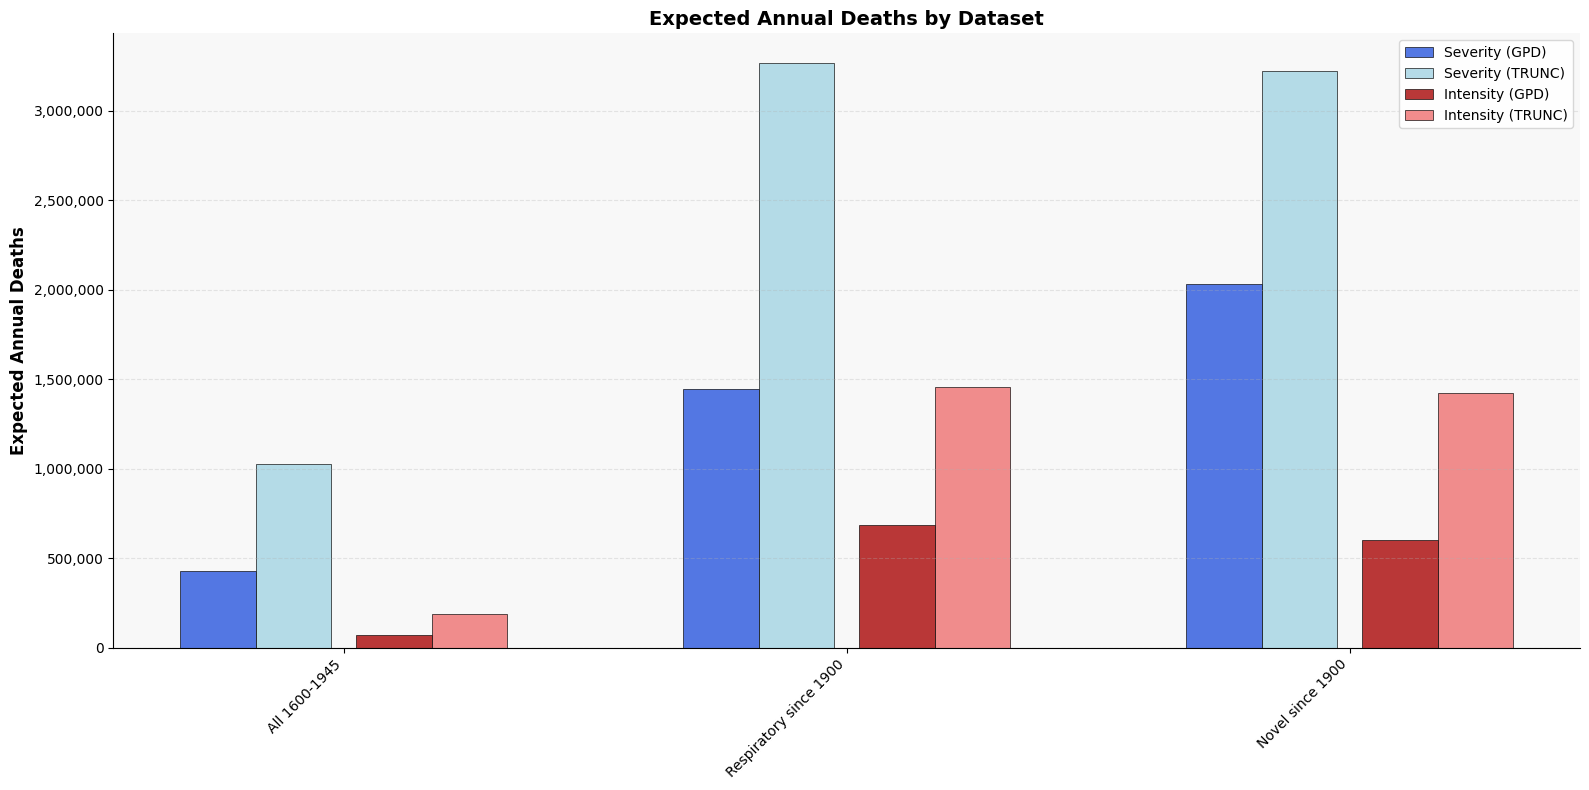

In [27]:
create_mortality_plot(selected_dfs=['All 1600-1945 (Marani)', 'Respiratory since 1900', 'Novel since 1900 (Bernstein)'])